# Two theories of the cognitive map, benchmarked head to head

**Paper 1 — Whittington, McCaffary, Bakermans & Behrens (2022).**
*How to build a cognitive map.* Nature Neuroscience 25, 1257–1272.
https://www.nature.com/articles/s41593-022-01153-y

**Paper 2 — Raju, Guntupalli, Zhou, Wendelken, Lázaro-Gredilla & George (2024).**
*Space is a latent sequence: A theory of the hippocampus.* Science Advances 10, eadm8470.
https://www.science.org/doi/10.1126/sciadv.adm8470

---

## What each paper actually claims

**Paper 1 is a review, not a single model.** It organises the space of
cognitive-map models into an ontology and argues for one branch of it: latent
structure should be carried by an **abstract structural code** (entorhinal,
grid-like, updated by **path integration** over actions) held *separately* from
a **sensory code**, with the hippocampus storing their **conjunction**. Its
flagship instantiation is the Tolman–Eichenbaum Machine (Whittington et al.,
Cell 2020). The promised payoff is generalisation: structure learned once
transfers to a new sensory world essentially for free.

**Paper 2 proposes one specific model and one specific reinterpretation.** Space
is not represented as space at all; it is an emergent property of **latent
higher-order sequence learning**. The model, the **clone-structured causal graph
(CSCG)**, is an action-conditioned HMM whose emission matrix is frozen into a
*clone* structure: many latent states share one observation, so the same
sensation can be split across different sequential contexts. Learning touches
only the transition tensor, by EM. The paper's sharper claim is methodological —
that Euclidean place-field mapping is itself a source of the field's anomalies.

**These are not merely different; paper 2 attacks paper 1's branch directly.**
It argues that TEMs do not learn latent graphs in aliased settings, do not
handle multiple graphs or latent transitive stitching, have been demonstrated
only in allocentric settings with a global coordinate system, and rely on
hard-coded loop-closing semantics of allocentric actions.

That disagreement is what this notebook measures. The experiments are chosen to
put each of those specific claims on a number, rather than to score generic
"accuracy".

---

## The ontology, and where each model sits

| Question | Factorised / TEM branch (paper 1) | CSCG (paper 2) |
|---|---|---|
| What is a latent state? | structure ⊗ sensory conjunction | a *clone*: an observation in a sequential context |
| Where does structure come from? | path integration over actions | transition statistics of the observation stream |
| Is space assumed? | yes — action algebra encodes translation | no — space is an *output*, never an input |
| How is a new environment learned? | Hebbian binding into episodic memory | EM on the transition tensor (or emissions) |
| What is the map, concretely? | weights of a generative model | an explicit, editable directed multigraph |
| Learning rule | gradient descent (meta-learned) | expectation–maximisation |
| Planning | not intrinsic | message passing / replay over the latent graph |

---

## The shared metric

Every model is scored on the same quantity wherever possible:

$$\text{bits/step} \;=\; -\log_2 p\!\left(x_{t+1} \mid x_{1:t},\, a_{1:t}\right)$$

the **online next-observation cost**. CSCG computes it by forward filtering over
clones; TEM-lite by retrieval from its Hebbian memory. Chance is
$\log_2 N_\text{obs}$. No model ever receives a location, a coordinate, or a
place field as input — place fields appear only at the very end, as the
*experimenter's* visualisation, which is precisely paper 2's point.

Secondary metrics: latent-state decodability, planning success and path
optimality, and wall-clock fitting time.

---

## Three honesty notes, up front

1. **TEM-lite is a reduction, not the published TEM.** It keeps the three
   commitments the theory is about (factorisation, path integration,
   conjunctive binding) and drops the variational inference scheme, the
   two-stream posterior over `g`, hierarchical sensory levels, and attractor
   retrieval. Official code:
   https://github.com/djcrw/generalising-structural-knowledge
2. **Paper 1 is a review**, so "paper 1's theory" here means the branch it
   advocates. The review itself is deliberately more ecumenical, and it
   explicitly includes CSCG-style clone models in its ontology.
3. **The benchmark is small.** Rooms of 40–120 latent states and minutes of CPU,
   not the scale either paper works at. Treat the numbers as a mechanism
   demonstration, not a verdict on which theory is true.

In [ ]:
#@title Setup
import time, copy, json
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    print("torch", torch.__version__)
except ImportError:
    raise SystemExit("Run  !pip install torch  first (Colab has it preinstalled).")

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

# FAST ~= 6 min total on a Colab CPU. FULL ~= 20 min and gives cleaner numbers.
PRESET = "FULL"   #@param ["FAST", "FULL"]

torch 2.11.0+cpu


## 1. Environments

Both theories are stated over the same object, so we implement it once: a
**deterministic labelled multigraph**. Latent nodes are never shown to a model;
actions label edges; observations label nodes and **alias** — the same sensation
occurs at many nodes. This is exactly paper 2's formalism, and it is a superset
of the structured-graph setting paper 1 assumes.

Two knobs matter for the comparison:

* `mode="ego"` builds an **egocentric** world: latent state is (cell, heading),
  actions are forward / turn-left / turn-right, and there is no compass. Paper 2
  argues this is the realistic setting and the one TEMs have not been shown to
  handle. Experiment E tests that.
* `resample_obs()` redraws sensory identities while holding topology **fixed**.
  This is the manipulation the factorised theory is built to exploit, and it
  drives Experiment C.

In [ ]:
"""Environments for the cognitive-map benchmark.

Everything is expressed as a deterministic labelled multigraph:
    states  -> latent nodes (never shown to the models)
    actions -> edge labels
    obs     -> aliased node labels (what the agent actually senses)

This is exactly the formalism used by Raju et al. (2024) and is also a
superset of the "structured graph" setting assumed by Whittington et al. (2022).
"""
import numpy as np


class World:
    """Deterministic labelled multigraph environment."""

    name = "world"

    def __init__(self, n_states, n_actions, trans, obs, coords=None, meta=None):
        # trans[s, a] = next state, or -1 if the action is unavailable in s
        self.trans = np.asarray(trans, dtype=np.int64)
        self.obs_of_state = np.asarray(obs, dtype=np.int64)
        self.n_states = int(n_states)
        self.n_actions = int(n_actions)
        self.n_obs = int(self.obs_of_state.max()) + 1
        self.coords = coords            # (n_states, 2) for plotting, may be None
        self.meta = meta or {}

    # ---------------------------------------------------------------- walks
    def random_walk(self, length, rng, start=None):
        """Uniform random walk over *available* actions.

        Returns (actions, observations, states). Following the CSCG
        convention, action[n] is the action taken *at* step n, leading to the
        state observed at step n+1.
        """
        rng = np.random.default_rng(rng) if not isinstance(rng, np.random.Generator) else rng
        s = int(rng.integers(self.n_states)) if start is None else int(start)
        while (self.trans[s] >= 0).sum() == 0:
            s = int(rng.integers(self.n_states))
        states = np.empty(length, dtype=np.int64)
        actions = np.empty(length, dtype=np.int64)
        for n in range(length):
            states[n] = s
            avail = np.flatnonzero(self.trans[s] >= 0)
            a = int(rng.choice(avail))
            actions[n] = a
            s = int(self.trans[s, a])
        obs = self.obs_of_state[states]
        # last action is not used (no successor observed); keep arrays aligned
        return actions, obs, states

    def resample_obs(self, rng, n_obs=None):
        """Return a copy of the world with a fresh random sensory binding.

        Topology (transition structure) is untouched -- only the labels change.
        This is the manipulation that separates the two theories: a factorised
        structure/sensory model should transfer instantly, a model whose latent
        states are tied to observations must relearn its emissions.
        """
        rng = np.random.default_rng(rng) if not isinstance(rng, np.random.Generator) else rng
        k = self.n_obs if n_obs is None else n_obs
        new_obs = rng.integers(0, k, size=self.n_states)
        # guarantee every symbol is used at least once
        new_obs[rng.permutation(self.n_states)[:k]] = np.arange(k)
        w = World(self.n_states, self.n_actions, self.trans, new_obs,
                  self.coords, dict(self.meta))
        w.name = self.name + "+resampled"
        return w


# --------------------------------------------------------------------- grids
def _grid_states(open_mask):
    idx = -np.ones(open_mask.shape, dtype=np.int64)
    cells = np.argwhere(open_mask)
    for i, (r, c) in enumerate(cells):
        idx[r, c] = i
    return idx, cells


def grid_world(open_mask, obs_map, mode="allo", name="grid"):
    """2-D room.

    mode="allo": 4 allocentric actions (N,S,W,E), latent state = cell.
    mode="ego" : 3 egocentric actions (forward, turn-left, turn-right),
                 latent state = (cell, heading).  The agent has no compass:
                 this is the setting Raju et al. argue is the realistic one.
    """
    open_mask = np.asarray(open_mask, dtype=bool)
    obs_map = np.asarray(obs_map, dtype=np.int64)
    idx, cells = _grid_states(open_mask)
    n_cells = len(cells)
    dirs = np.array([[-1, 0], [1, 0], [0, -1], [0, 1]])  # N S W E

    if mode == "allo":
        trans = -np.ones((n_cells, 4), dtype=np.int64)
        for i, (r, c) in enumerate(cells):
            for a, (dr, dc) in enumerate(dirs):
                rr, cc = r + dr, c + dc
                if 0 <= rr < open_mask.shape[0] and 0 <= cc < open_mask.shape[1] \
                        and open_mask[rr, cc]:
                    trans[i, a] = idx[rr, cc]
        obs = obs_map[cells[:, 0], cells[:, 1]]
        w = World(n_cells, 4, trans, obs, coords=cells.astype(float),
                  meta=dict(shape=open_mask.shape, mode="allo",
                            cell_of_state=np.arange(n_cells), cells=cells))
    elif mode == "ego":
        # state = cell * 4 + heading ; actions = 0 forward, 1 left, 2 right
        n = n_cells * 4
        trans = -np.ones((n, 3), dtype=np.int64)
        for i, (r, c) in enumerate(cells):
            for h in range(4):
                s = i * 4 + h
                dr, dc = dirs[h]
                rr, cc = r + dr, c + dc
                if 0 <= rr < open_mask.shape[0] and 0 <= cc < open_mask.shape[1] \
                        and open_mask[rr, cc]:
                    trans[s, 0] = idx[rr, cc] * 4 + h
                # turning is always available; N,S,W,E -> left/right mapping
                left = {0: 2, 2: 1, 1: 3, 3: 0}[h]
                right = {0: 3, 3: 1, 1: 2, 2: 0}[h]
                trans[s, 1] = i * 4 + left
                trans[s, 2] = i * 4 + right
        obs = np.repeat(obs_map[cells[:, 0], cells[:, 1]], 4)
        coords = np.repeat(cells.astype(float), 4, axis=0)
        w = World(n, 3, trans, obs, coords=coords,
                  meta=dict(shape=open_mask.shape, mode="ego",
                            cell_of_state=np.repeat(np.arange(n_cells), 4),
                            heading_of_state=np.tile(np.arange(4), n_cells),
                            cells=cells))
    else:
        raise ValueError(mode)
    w.name = name
    return w


def rect_room(h, w, n_obs=6, rng=0, mode="allo", name=None):
    rng = np.random.default_rng(rng)
    open_mask = np.ones((h, w), dtype=bool)
    obs_map = rng.integers(0, n_obs, size=(h, w))
    return grid_world(open_mask, obs_map, mode=mode,
                      name=name or f"room{h}x{w}")


def uniform_room(h, w, rng=0, mode="allo", name=None):
    """Uniform interior, distinct border symbols -- the classic CSCG setting.

    Interior is a single repeated symbol, so *no* local sensation identifies a
    location: the model can only succeed by using sequential context.
    """
    obs_map = np.zeros((h, w), dtype=np.int64)
    obs_map[0, :] = 1
    obs_map[-1, :] = 2
    obs_map[:, 0] = 3
    obs_map[:, -1] = 4
    obs_map[0, 0] = 5
    obs_map[0, -1] = 6
    obs_map[-1, 0] = 7
    obs_map[-1, -1] = 8
    open_mask = np.ones((h, w), dtype=bool)
    return grid_world(open_mask, obs_map, mode=mode,
                      name=name or f"uniform{h}x{w}")


def two_room_world(h=5, w=5, corridor=3, n_obs=6, rng=0, mode="allo",
                   identical=True):
    """Two rooms joined by a corridor; optionally visually identical.

    Used for the place-field-repetition experiment (Fuhs et al. phenomenon).
    """
    rng = np.random.default_rng(rng)
    H = h + 2
    W = w * 2 + corridor + 2
    open_mask = np.zeros((H, W), dtype=bool)
    open_mask[1:h + 1, 1:w + 1] = True
    open_mask[1:h + 1, w + 1 + corridor:w + 1 + corridor + w] = True
    mid = 1 + h // 2
    open_mask[mid, w + 1:w + 1 + corridor] = True
    obs_map = np.zeros((H, W), dtype=np.int64)
    roomA = rng.integers(0, n_obs, size=(h, w))
    roomB = roomA.copy() if identical else rng.integers(0, n_obs, size=(h, w))
    obs_map[1:h + 1, 1:w + 1] = roomA
    obs_map[1:h + 1, w + 1 + corridor:w + 1 + corridor + w] = roomB
    obs_map[mid, w + 1:w + 1 + corridor] = n_obs  # corridor symbol
    return grid_world(open_mask, obs_map, mode=mode,
                      name="two_rooms" + ("_identical" if identical else ""))


# ------------------------------------------------------- non-spatial graphs
def random_regular_world(n_states=36, n_actions=4, n_obs=6, rng=0,
                         name="relational"):
    """Random reversible relational graph: actions are abstract relations.

    Nothing about this graph is Euclidean, which is the point -- both theories
    claim to cover non-spatial relational structure, so both should cope.
    """
    rng = np.random.default_rng(rng)
    assert n_actions % 2 == 0, "actions come in inverse pairs"
    trans = -np.ones((n_states, n_actions), dtype=np.int64)
    for a in range(0, n_actions, 2):
        while True:
            perm = rng.permutation(n_states)
            if np.all(perm != np.arange(n_states)):
                break
        trans[:, a] = perm                 # relation
        trans[perm, a + 1] = np.arange(n_states)   # its inverse
    obs = rng.integers(0, n_obs, size=n_states)
    obs[rng.permutation(n_states)[:n_obs]] = np.arange(n_obs)
    w = World(n_states, n_actions, trans, obs)
    w.name = name
    return w


def hierarchy_world(depth=4, branch=2, n_obs=4, rng=0, name="hierarchy"):
    """Rooted tree with up/down relations -- a non-Euclidean, non-cyclic map."""
    rng = np.random.default_rng(rng)
    nodes, children, parent = [0], {}, {0: -1}
    frontier, nxt = [0], 1
    for _ in range(depth - 1):
        new = []
        for p in frontier:
            children[p] = []
            for _ in range(branch):
                children[p].append(nxt)
                parent[nxt] = p
                nodes.append(nxt)
                new.append(nxt)
                nxt += 1
        frontier = new
    n = nxt
    n_actions = branch + 1        # down_1..down_b, up
    trans = -np.ones((n, n_actions), dtype=np.int64)
    for p, ch in children.items():
        for i, c in enumerate(ch):
            trans[p, i] = c
    for c, p in parent.items():
        if p >= 0:
            trans[c, branch] = p
    obs = rng.integers(0, n_obs, size=n)
    w = World(n, n_actions, trans, obs)
    w.name = name
    return w


def restricted_walk(world, allowed_mask, length, rng, start=None):
    """Random walk confined to a subset of latent states.

    Used to give an agent temporally disjoint, spatially partial experience of
    an environment -- the setup for testing transitive stitching.
    """
    rng = (np.random.default_rng(rng)
           if not isinstance(rng, np.random.Generator) else rng)
    allowed = np.flatnonzero(allowed_mask)
    s = int(rng.choice(allowed)) if start is None else int(start)
    states = np.empty(length, dtype=np.int64)
    actions = np.empty(length, dtype=np.int64)
    for n in range(length):
        states[n] = s
        cand = [a for a in range(world.n_actions)
                if world.trans[s, a] >= 0 and allowed_mask[world.trans[s, a]]]
        if not cand:
            s = int(rng.choice(allowed))
            states[n] = s
            cand = [a for a in range(world.n_actions)
                    if world.trans[s, a] >= 0 and allowed_mask[world.trans[s, a]]]
        a = int(rng.choice(cand))
        actions[n] = a
        s = int(world.trans[s, a])
    return actions, world.obs_of_state[states], states


def geodesic_distances(world):
    """All-pairs shortest path over the true latent graph (BFS)."""
    n = world.n_states
    D = np.full((n, n), np.inf)
    for src in range(n):
        D[src, src] = 0
        frontier, d = [src], 0
        while frontier:
            d += 1
            new = []
            for s in frontier:
                for a in range(world.n_actions):
                    t = world.trans[s, a]
                    if t >= 0 and np.isinf(D[src, t]):
                        D[src, t] = d
                        new.append(int(t))
            frontier = new
    return D

## 2. Paper 2's model — CSCG

Written directly from the EM equations in the Science Advances paper
(its Eqs. 12–17). The emission matrix is frozen into the clone structure, so
learning only reshapes the action-conditioned transition tensor
$T[a,i,j] = P(z_{t+1}=j \mid z_t=i, a_t=a)$.

Three capabilities matter later and are implemented here:

* `learn_em_T` accepts a **list of temporally disjoint episodes** — needed to
  test transitive stitching.
* `learn_em_E` freezes `T` and relearns only emissions — the paper's own
  transfer protocol, treating the learned graph as a reusable schema.
* `plan` does shortest-path message passing over the **learned latent graph**,
  with no Euclidean coordinates anywhere.

One implementation note: the E-step is vectorised by grouping timesteps by
their `(action, obs_t, obs_{t+1})` triple, which is what makes this run in
seconds rather than minutes.

In [ ]:
"""Clone-structured causal graph (CSCG).

Implemented directly from the EM equations in Raju et al. (2024),
"Space is a latent sequence: A theory of the hippocampus", Sci. Adv. 10, eadm8470.

The model is an action-conditioned HMM whose emission matrix is frozen into a
*clone* structure: hidden state i deterministically emits observation obs(i),
and many hidden states share the same observation. Learning therefore only
touches the transition tensor T[a, i, j].
"""
import numpy as np

EPS = 1e-12


class CSCG:
    def __init__(self, n_clones, n_actions, pseudocount=1e-2, seed=0):
        """n_clones[o] = number of latent states allocated to observation o."""
        self.n_clones = np.asarray(n_clones, dtype=np.int64)
        self.n_obs = len(self.n_clones)
        self.n_actions = int(n_actions)
        self.n_states = int(self.n_clones.sum())
        self.pseudocount = pseudocount
        self.rng = np.random.default_rng(seed)
        # block boundaries for the clones of each observation
        self.loc = np.hstack(([0], np.cumsum(self.n_clones)))
        self.obs_of_state = np.repeat(np.arange(self.n_obs), self.n_clones)
        self.T = self.rng.random((self.n_actions, self.n_states, self.n_states))
        self._normalise_T()
        self.pi = np.ones(self.n_states) / self.n_states
        # emission matrix, only used for transfer to a new sensory world
        self.E = np.zeros((self.n_states, self.n_obs))
        self.E[np.arange(self.n_states), self.obs_of_state] = 1.0

    # ------------------------------------------------------------- helpers
    def _normalise_T(self):
        self.T /= self.T.sum(axis=2, keepdims=True) + EPS

    def _blk(self, a, u, v):
        """T[a] restricted to clones(u) x clones(v)."""
        return self.T[a, self.loc[u]:self.loc[u + 1], self.loc[v]:self.loc[v + 1]]

    # ---------------------------------------------------- forward/backward
    def _forward(self, a, x, store=True):
        """Scaled forward pass. Returns (alphas, log-evidence in nats)."""
        N = len(x)
        alphas = [] if store else None
        alpha = self.pi[self.loc[x[0]]:self.loc[x[0] + 1]].copy()
        z = alpha.sum() + EPS
        alpha /= z
        ll = np.log(z)
        if store:
            alphas.append(alpha)
        for n in range(N - 1):
            Tb = self._blk(a[n], x[n], x[n + 1])
            alpha = Tb.T @ alpha
            z = alpha.sum() + EPS
            alpha /= z
            ll += np.log(z)
            if store:
                alphas.append(alpha)
        return alphas, ll

    def _backward(self, a, x):
        N = len(x)
        betas = [None] * N
        beta = np.ones(self.n_clones[x[-1]])
        beta /= beta.sum() + EPS
        betas[-1] = beta
        for n in range(N - 2, -1, -1):
            Tb = self._blk(a[n], x[n], x[n + 1])
            beta = Tb @ beta
            beta /= beta.sum() + EPS
            betas[n] = beta
        return betas

    # ------------------------------------------------------------ learning
    def _triple_groups(self, a, x):
        """Cache: timesteps grouped by (action, obs_t, obs_{t+1})."""
        key = (id(a), id(x), len(x))
        if getattr(self, "_grp_key", None) == key:
            return self._grp
        code = (a[:-1] * self.n_obs + x[:-1]) * self.n_obs + x[1:]
        order = np.argsort(code, kind="stable")
        cs = code[order]
        bounds = np.flatnonzero(np.diff(cs)) + 1
        groups = []
        for idxs in np.split(order, bounds):
            c = int(cs[np.searchsorted(cs, code[idxs[0]])])
            w = c % self.n_obs
            v = (c // self.n_obs) % self.n_obs
            u = c // (self.n_obs * self.n_obs)
            groups.append((u, v, w, idxs))
        self._grp_key, self._grp = key, groups
        return groups

    def _estep_counts(self, a, x):
        """Accumulated transition counts and log-evidence for one episode."""
        groups = self._triple_groups(a, x)
        maxM = int(self.n_clones.max())
        N = len(x)
        alphas, ll = self._forward(a, x)
        betas = self._backward(a, x)
        A = np.zeros((N, maxM))
        B = np.zeros((N, maxM))
        for n in range(N):
            A[n, :len(alphas[n])] = alphas[n]
            B[n, :len(betas[n])] = betas[n]
        counts = np.zeros_like(self.T)
        for (u, v, w, idxs) in groups:
            Mv, Mw = self.n_clones[v], self.n_clones[w]
            Tb = self._blk(u, v, w)
            Ag = A[idxs, :Mv]
            Bg = B[idxs + 1, :Mw]
            s = np.maximum(np.einsum("gi,ij,gj->g", Ag, Tb, Bg), EPS)
            counts[u, self.loc[v]:self.loc[v + 1],
                   self.loc[w]:self.loc[w + 1]] += Tb * ((Ag / s[:, None]).T @ Bg)
        return counts, ll, N

    @staticmethod
    def _as_episodes(a, x):
        """Accept a single (a, x) pair or a list of episodes."""
        if isinstance(a, (list, tuple)) and not np.isscalar(a[0]) \
                and np.ndim(a[0]) == 1:
            return [(np.ascontiguousarray(ai, dtype=np.int64),
                     np.ascontiguousarray(xi, dtype=np.int64))
                    for ai, xi in zip(a, x)]
        return [(np.ascontiguousarray(a, dtype=np.int64),
                 np.ascontiguousarray(x, dtype=np.int64))]

    def learn_em_T(self, a, x, n_iter=50, tol=1e-6, verbose=False):
        """Baum-Welch on the transition tensor (Eqs. 12-17 of the paper).

        Accepts one sequence, or a list of temporally disjoint episodes -- the
        latter is what the transitive-stitching experiment needs.
        """
        eps_ = self._as_episodes(a, x)
        history, prev = [], -np.inf
        for it in range(n_iter):
            counts = np.zeros_like(self.T)
            ll_tot, n_tot = 0.0, 0
            for (ai, xi) in eps_:
                c, ll, N = self._estep_counts(ai, xi)
                counts += c
                ll_tot += ll
                n_tot += N
            counts += self.pseudocount
            self.T = counts / counts.sum(axis=2, keepdims=True)
            bps = -ll_tot / np.log(2) / n_tot
            history.append(bps)
            if verbose and (it % 10 == 0 or it == n_iter - 1):
                print(f"  EM iter {it:3d}  bits/step {bps:.4f}")
            if abs(prev - ll_tot) < tol * abs(ll_tot):
                break
            prev = ll_tot
        return np.array(history)

    def learn_viterbi_T(self, a, x, n_iter=20):
        """Hard/greedy EM: collapses the superposition into a sparse graph."""
        eps_ = self._as_episodes(a, x)
        history = []
        for _ in range(n_iter):
            counts = np.zeros_like(self.T)
            for (ai, xi) in eps_:
                states = self.decode(ai, xi)
                np.add.at(counts, (ai[:-1], states[:-1], states[1:]), 1.0)
            counts += self.pseudocount
            self.T = counts / counts.sum(axis=2, keepdims=True)
            history.append(float(np.mean([self.bits_per_step(ai, xi)
                                          for ai, xi in eps_])))
        return np.array(history)

    def learn_em_E(self, a, x, n_iter=30, preserve_clone_structure=False):
        """Transfer: freeze T (the schema), relearn only the emission matrix.

        This is the transfer protocol of Raju et al. Fig. 2D.
        """
        a = np.asarray(a, dtype=np.int64)
        x = np.asarray(x, dtype=np.int64)
        n_obs_new = int(x.max()) + 1
        E = self.rng.random((self.n_states, n_obs_new)) + 1.0
        E /= E.sum(axis=1, keepdims=True)
        history = []
        for _ in range(n_iter):
            # forward-backward with a general (non-clone) emission matrix
            N = len(x)
            alpha = self.pi * E[:, x[0]]
            z = alpha.sum() + EPS
            alpha /= z
            ll = np.log(z)
            alphas = [alpha]
            for n in range(N - 1):
                alpha = (self.T[a[n]].T @ alpha) * E[:, x[n + 1]]
                z = alpha.sum() + EPS
                alpha /= z
                ll += np.log(z)
                alphas.append(alpha)
            beta = np.ones(self.n_states)
            betas = [None] * N
            betas[-1] = beta / beta.sum()
            for n in range(N - 2, -1, -1):
                beta = self.T[a[n]] @ (betas[n + 1] * E[:, x[n + 1]])
                betas[n] = beta / (beta.sum() + EPS)
            gam = np.array([alphas[n] * betas[n] for n in range(N)])
            gam /= gam.sum(axis=1, keepdims=True) + EPS
            if preserve_clone_structure:
                for o in range(self.n_obs):
                    blk = gam[:, self.loc[o]:self.loc[o + 1]]
                    gam[:, self.loc[o]:self.loc[o + 1]] = \
                        blk.sum(axis=1, keepdims=True) / max(self.n_clones[o], 1)
            newE = np.zeros_like(E)
            for j in range(n_obs_new):
                newE[:, j] = gam[x == j].sum(axis=0)
            newE += 1e-6
            E = newE / newE.sum(axis=1, keepdims=True)
            history.append(-ll / np.log(2) / N)
        self.E_transfer = E
        return np.array(history)

    # ----------------------------------------------------------- inference
    def decode(self, a, x):
        """Viterbi most-likely clone sequence."""
        a = np.asarray(a, dtype=np.int64)
        x = np.asarray(x, dtype=np.int64)
        N = len(x)
        logT = np.log(self.T + EPS)
        score = np.log(self.pi[self.loc[x[0]]:self.loc[x[0] + 1]] + EPS)
        back = []
        for n in range(N - 1):
            Lb = logT[a[n], self.loc[x[n]]:self.loc[x[n] + 1],
                      self.loc[x[n + 1]]:self.loc[x[n + 1] + 1]]
            tot = score[:, None] + Lb
            arg = tot.argmax(axis=0)
            score = tot.max(axis=0)
            back.append(arg)
        states = np.empty(N, dtype=np.int64)
        j = int(score.argmax())
        states[-1] = self.loc[x[-1]] + j
        for n in range(N - 2, -1, -1):
            j = int(back[n][j])
            states[n] = self.loc[x[n]] + j
        return states

    def filter_posteriors(self, a, x):
        """Online posterior over clones, p(z_n | x_1..n, a_1..n)."""
        a = np.asarray(a, dtype=np.int64)
        x = np.asarray(x, dtype=np.int64)
        alphas, _ = self._forward(a, x)
        out = np.zeros((len(x), self.n_states))
        for n, al in enumerate(alphas):
            out[n, self.loc[x[n]]:self.loc[x[n] + 1]] = al
        return out

    def bits_per_step(self, a, x):
        """Online next-observation predictive cost -- the shared benchmark metric."""
        return float(self.predictive_bits(a, x).mean())

    def predictive_bits(self, a, x):
        a = np.asarray(a, dtype=np.int64)
        x = np.asarray(x, dtype=np.int64)
        N = len(x)
        alpha = self.pi[self.loc[x[0]]:self.loc[x[0] + 1]].copy()
        alpha /= alpha.sum() + EPS
        bits = np.zeros(N - 1)
        for n in range(N - 1):
            full = np.zeros(self.n_states)
            full[self.loc[x[n]]:self.loc[x[n] + 1]] = alpha
            pred_state = self.T[a[n]].T @ full
            pred_obs = np.array([pred_state[self.loc[o]:self.loc[o + 1]].sum()
                                 for o in range(self.n_obs)])
            pred_obs = np.maximum(pred_obs, EPS)
            pred_obs /= pred_obs.sum()
            bits[n] = -np.log2(pred_obs[x[n + 1]])
            alpha = pred_state[self.loc[x[n + 1]]:self.loc[x[n + 1] + 1]]
            alpha = alpha / (alpha.sum() + EPS)
        return bits

    # ------------------------------------------------------------ planning
    def graph(self, thresh=0.1):
        """Binarise the learned transition tensor into a labelled digraph."""
        return self.T > thresh

    def plan(self, start_state, goal_state, thresh=0.1, max_len=200):
        """Shortest action path start -> goal on the *learned* latent graph.

        This is the model's vicarious evaluation: message passing over clones,
        with no Euclidean coordinates anywhere. Returns (actions, state path).
        """
        adj = self.graph(thresh)                       # (A, S, S) bool
        prev = {int(start_state): (None, None)}
        frontier = [int(start_state)]
        for _ in range(max_len):
            if goal_state in prev:
                break
            new = []
            for s in frontier:
                for a in range(self.n_actions):
                    for t in np.flatnonzero(adj[a, s]):
                        t = int(t)
                        if t not in prev:
                            prev[t] = (s, a)
                            new.append(t)
            if not new:
                break
            frontier = new
        if goal_state not in prev:
            return None, None
        acts, path, s = [], [int(goal_state)], int(goal_state)
        while prev[s][0] is not None:
            p, a = prev[s]
            acts.append(a)
            path.append(p)
            s = p
        return acts[::-1], path[::-1]

## 3. Paper 1's branch — TEM-lite

Read the docstring: it states exactly what is kept and what is dropped.

The single most important line in this cell is the `action_inverses` argument.
When supplied, the model is *told* which actions undo which, so loops close by
construction. Paper 2's critique is precisely that TEMs "rely on the hard-coded
loop-closing semantics of allocentric actions." Rather than argue about it, we
build the assumption in explicitly, then withdraw it in the ablation and break
it in Experiment E.

This was not a design preference. During development, the assumption-free
version — free $d_g \times d_g$ matrices per action — **did not train at all**,
sitting at chance. With random operators, returning to a cell yields a different
structural code, the memory is never queried consistently, and there is no
gradient signal about *where* the agent is. The ablation at the end reproduces
that failure so you can see it rather than take my word for it.

In [ ]:
"""TEM-lite: a tractable implementation of the FACTORISED cognitive-map theory.

This follows the "structure x sensory, bound in the hippocampus" branch of the
ontology in Whittington, McCaffary, Bakermans & Behrens (2022),
"How to build a cognitive map", Nat. Neurosci. 25, 1257-1272, whose flagship
instantiation is the Tolman-Eichenbaum Machine (Whittington et al., Cell 2020).

Three commitments are kept, because they are what the theory is *about*:

  1. FACTORISATION      an abstract structural code g (entorhinal / grid-like)
                        is kept separate from a sensory code w.
  2. PATH INTEGRATION   g is *generated* by an action-conditioned operator,
                        g_{t+1} = f(W_{a_t} g_t) -- never retrieved from sense.
  3. CONJUNCTIVE BINDING  a hippocampal memory stores the outer product of
                        structure and sense, M <- M + w_t g_t^T, and prediction
                        is retrieval from it: x_hat = dec(M g_{t+1}).

Structure (theta, phi0) is meta-learned ACROSS environments and reused; the
memory M is environment-specific and written online WITHIN one episode. That
split is exactly the mechanism the review claims buys zero-shot generalisation.

Two structural codes are provided:

  structure="modules"  (default)  K ring-attractor modules. Module k holds a
      phase phi_k updated additively, phi_k <- phi_k + theta_{k,a}, and is read
      out by P von-Mises-tuned units. Phases add, so translations commute and
      loops close *by construction*. This is the grid-module code the review
      describes; the learned quantities are the frequencies/orientations.

  structure="general"  free d_g x d_g matrices per action, no built-in algebra.
      Included as an honesty check: it is the assumption-free version, and in
      this notebook it does not train to a useful solution within the compute
      budget. Its failure is a result, not a bug to hide.

IMPORTANT, and the subject of Experiment E: when action_inverses is supplied,
the model is told which actions undo which (theta_{k,inv(a)} = -theta_{k,a}).
Raju et al. (2024) argue precisely that TEMs "rely on the hard-coded
loop-closing semantics of allocentric actions". We implement that assumption
explicitly and then test what happens when it is withdrawn, rather than
arguing about it in prose.

Deliberately omitted relative to the published TEM: variational inference, the
two-stream generative/inference posterior over g, hierarchical sensory levels,
and attractor-based memory retrieval.
Official TEM code: https://github.com/djcrw/generalising-structural-knowledge
"""
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


class TEMLite(nn.Module):
    def __init__(self, n_actions, n_obs, structure="modules", n_modules=8,
                 n_phase=8, d_x=24, d_g=48, kappa=3.0, action_inverses=None,
                 mem_decay=1.0, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.n_actions, self.n_obs = n_actions, n_obs
        self.structure, self.d_x, self.mem_decay = structure, d_x, mem_decay
        self.inv = action_inverses

        if structure == "modules":
            self.K, self.P = n_modules, n_phase
            self.d_g = n_modules * n_phase
            if action_inverses is not None:
                free = sorted({min(a, action_inverses[a])
                               for a in range(n_actions)})
                self.free = free
                self.register_buffer(
                    "sgn", torch.tensor([1.0 if a in free else -1.0
                                         for a in range(n_actions)]))
                self.register_buffer(
                    "pair", torch.tensor([free.index(min(a, action_inverses[a]))
                                          for a in range(n_actions)]))
                n_free = len(free)
            else:
                self.free, n_free = list(range(n_actions)), n_actions
            self.theta_free = nn.Parameter(
                torch.rand(self.K, n_free) * 2 * np.pi - np.pi)
            self.phi0 = nn.Parameter(torch.zeros(self.K))
            self.log_kappa = nn.Parameter(torch.tensor(float(np.log(kappa))))
            self.register_buffer("bins",
                                 2 * np.pi * torch.arange(n_phase) / n_phase)
        elif structure == "general":
            self.d_g = d_g
            W = torch.stack([torch.linalg.qr(torch.randn(d_g, d_g))[0]
                             for _ in range(n_actions)])
            self.W = nn.Parameter(W)
            self.g0 = nn.Parameter(torch.randn(d_g) * 0.5)
        else:
            raise ValueError(structure)

        self.emb = nn.Embedding(n_obs, d_x)
        self.temp = nn.Parameter(torch.tensor(2.0))

    # ------------------------------------------------------ structural code
    def theta(self):
        if self.inv is None:
            return self.theta_free
        return self.theta_free[:, self.pair] * self.sgn

    def _code(self, phi):
        """Ring-attractor readout: (B, K) phases -> (B, K*P) unit-norm code."""
        d = phi.unsqueeze(-1) - self.bins
        g = torch.exp(torch.exp(self.log_kappa) * torch.cos(d))
        g = g / g.sum(-1, keepdim=True)
        return F.normalize(g.reshape(phi.shape[0], -1), dim=-1)

    # ------------------------------------------------------------- rollout
    def rollout(self, actions, obs, return_codes=False):
        """One batch of episodes. actions/obs: LongTensor (B, T).

        An episode *is* an environment: memory starts empty and is never
        carried across episodes. Returns next-obs logits (B, T-1, n_obs).
        """
        B, T = obs.shape
        dev = obs.device
        if self.structure == "modules":
            th = self.theta()
            phi = self.phi0.expand(B, self.K).contiguous()
            g = self._code(phi)
        else:
            g = F.normalize(self.g0, dim=-1).expand(B, self.d_g).contiguous()
        M = torch.zeros(B, self.d_x, self.d_g, device=dev)
        logits, gs, ps = [], [], []
        for t in range(T - 1):
            w = self.emb(obs[:, t])
            M = self.mem_decay * M + torch.bmm(w.unsqueeze(-1), g.unsqueeze(1))
            if return_codes:
                gs.append(g)
                ps.append((w.unsqueeze(-1) * g.unsqueeze(1)).reshape(B, -1))
            if self.structure == "modules":                 # path integration
                phi = phi + th[:, actions[:, t]].T
                g = self._code(phi)
            else:
                g = F.normalize(torch.bmm(self.W[actions[:, t]],
                                          g.unsqueeze(-1)).squeeze(-1), dim=-1)
            r = F.normalize(torch.bmm(M, g.unsqueeze(-1)).squeeze(-1), dim=-1)
            logits.append((r @ self.emb.weight.T) * self.temp)
        logits = torch.stack(logits, 1)
        if return_codes:
            return logits, torch.stack(gs, 1), torch.stack(ps, 1)
        return logits

    def loss(self, actions, obs):
        logits = self.rollout(actions, obs)
        return F.cross_entropy(logits.reshape(-1, self.n_obs),
                               obs[:, 1:].reshape(-1))

    @torch.no_grad()
    def predictive_bits(self, actions, obs):
        """Online next-observation cost in bits -- identical metric to CSCG."""
        logits = self.rollout(actions, obs)
        lp = F.log_softmax(logits, dim=-1)
        b = -lp.gather(-1, obs[:, 1:].unsqueeze(-1)).squeeze(-1) / np.log(2)
        return b.cpu().numpy()


# --------------------------------------------------------------------- data
def episodes_from_world(world, n_eps, length, rng, resample_sensory=True,
                        n_obs=None):
    """Walks in one world; each episode optionally gets a fresh sensory binding.

    Topology is held fixed while sensory identities are redrawn -- the
    manipulation the factorised theory is built to exploit.
    """
    rng = (np.random.default_rng(rng)
           if not isinstance(rng, np.random.Generator) else rng)
    k = world.n_obs if n_obs is None else n_obs
    A = np.zeros((n_eps, length), dtype=np.int64)
    X = np.zeros((n_eps, length), dtype=np.int64)
    S = np.zeros((n_eps, length), dtype=np.int64)
    for i in range(n_eps):
        a, _, s = world.random_walk(length, rng)
        if resample_sensory:
            binding = rng.integers(0, k, size=world.n_states)
            binding[rng.permutation(world.n_states)[:k]] = np.arange(k)
        else:
            binding = world.obs_of_state
        A[i], X[i], S[i] = a, binding[s], s
    return A, X, S


def train_tem(model, world, steps=250, batch=32, length=100, lr=3e-2,
              rng=0, resample_sensory=True, device="cpu", verbose=True,
              log_every=50):
    """Meta-train the structural code across many sensory environments."""
    rng = np.random.default_rng(rng)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device).train()
    hist = []
    for it in range(steps):
        A, X, _ = episodes_from_world(world, batch, length, rng,
                                      resample_sensory=resample_sensory)
        at = torch.as_tensor(A, device=device)
        xt = torch.as_tensor(X, device=device)
        loss = model.loss(at, xt)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        hist.append(loss.item() / np.log(2))
        if verbose and (it % log_every == 0 or it == steps - 1):
            print(f"  TEM step {it:4d}  train bits/step {hist[-1]:.4f}")
    return np.array(hist)


GRID_INVERSES = {0: 1, 1: 0, 2: 3, 3: 2}      # N<->S, W<->E for allo grids


def relational_inverses(n_actions):
    """random_regular_world builds actions in inverse pairs (2k, 2k+1)."""
    return {a: (a + 1 if a % 2 == 0 else a - 1) for a in range(n_actions)}

## 4. Metrics, baselines and the experiment harness

Two baselines are included because paper 2 names them:

* **First-order model** (CSCG with exactly one clone per observation). This *is*
  the "sensations are states" assumption, made explicit and measurable.
* **Successor representation**, scored two ways — over true states (the oracle
  it is usually handed) and over observations (what an animal actually gets when
  sensations alias). Paper 2's objection to SR is that it "assumes that
  sensations directly correspond to locations"; `sr_distance_quality` turns that
  objection into a rank correlation.

In [ ]:
"""Shared metrics, baselines and experiments for the two-theory benchmark.

Every model is scored on the SAME quantity wherever possible:

    online next-observation cost, in bits/step
        -log2 p(x_{t+1} | x_{1..t}, a_{1..t})

This is the one number both theories are committed to: CSCG computes it by
forward filtering over clones, TEM-lite by retrieval from its Hebbian memory.
No model ever sees a location, a coordinate, or a place field during learning.
"""
import time
import numpy as np
import torch



# ----------------------------------------------------------------- metrics
def purity(true, pred):
    """Fraction of steps whose latent code identifies the true state."""
    return sum(np.bincount(true[pred == c]).max()
               for c in np.unique(pred)) / len(true)


def decode_accuracy_discrete(codes, states):
    """Majority map learned on the first half, scored on the second."""
    h = len(states) // 2
    mapping = {}
    for c in np.unique(codes[:h]):
        mapping[c] = np.bincount(states[:h][codes[:h] == c]).argmax()
    pred = np.array([mapping.get(c, -1) for c in codes[h:]])
    return float((pred == states[h:]).mean())


def decode_accuracy_continuous(codes, states, max_ref=4000):
    """1-nearest-neighbour readout of latent state from a continuous code."""
    h = len(states) // 2
    ref, ref_y = codes[:h][:max_ref], states[:h][:max_ref]
    q, q_y = codes[h:][:max_ref], states[h:][:max_ref]
    ref = ref / (np.linalg.norm(ref, axis=1, keepdims=True) + 1e-9)
    qn = q / (np.linalg.norm(q, axis=1, keepdims=True) + 1e-9)
    nn = (qn @ ref.T).argmax(1)
    return float((ref_y[nn] == q_y).mean())


def decode_accuracy_episodes(codes, states, max_ref=1500):
    """Within-episode 1-NN readout of latent state from a continuous code.

    TEM's structural code is path-integrated from the start of the episode, so
    it encodes displacement from the episode's origin rather than an absolute
    label. Decoding is therefore only meaningful within an episode; pooling
    across episodes with different start states would score near zero for a
    perfectly good code.
    """
    accs = []
    for b in range(codes.shape[0]):
        c, y = codes[b], states[b]
        h = len(y) // 2
        ref = c[:h][:max_ref]
        ref = ref / (np.linalg.norm(ref, axis=1, keepdims=True) + 1e-9)
        q = c[h:][:max_ref]
        qn = q / (np.linalg.norm(q, axis=1, keepdims=True) + 1e-9)
        nn = (qn @ ref.T).argmax(1)
        accs.append((y[:h][:max_ref][nn] == y[h:][:max_ref]).mean())
    return float(np.mean(accs))


def spearman(a, b):
    ra = np.argsort(np.argsort(a)).astype(float)
    rb = np.argsort(np.argsort(b)).astype(float)
    ra -= ra.mean()
    rb -= rb.mean()
    return float((ra @ rb) / (np.linalg.norm(ra) * np.linalg.norm(rb) + 1e-12))


# --------------------------------------------------------------- baselines
def markov_baseline(world, a, x, n_iter=1):
    """CSCG with exactly one clone per observation.

    This IS the "sensations are states" assumption that the successor
    representation and other first-order models make. Raju et al. argue it
    cannot work under aliasing; here that claim is simply measured.
    """
    m = CSCG(np.ones(world.n_obs, dtype=int), world.n_actions,
             pseudocount=1e-3, seed=0)
    m.learn_em_T(a, x, n_iter=n_iter)
    return m


def successor_representation(seq_states, n_states, gamma=0.95, lr=0.1,
                             n_pass=3):
    """TD-learned SR over whatever the model treats as a state."""
    M = np.eye(n_states)
    for _ in range(n_pass):
        for t in range(len(seq_states) - 1):
            s, s2 = seq_states[t], seq_states[t + 1]
            e = np.zeros(n_states)
            e[s] = 1.0
            M[s] += lr * (e + gamma * M[s2] - M[s])
    return M


def sr_distance_quality(world, states, obs, gamma=0.95):
    """Does the SR recover the metric of the environment?

    Computed twice: over TRUE states (the oracle the SR is usually given) and
    over OBSERVATIONS (what an animal actually receives when sensations alias).
    """
    D = geodesic_distances(world)
    M_true = successor_representation(states, world.n_states, gamma)
    dist_true = -np.log(M_true + 1e-6)
    M_obs = successor_representation(obs, world.n_obs, gamma)
    dist_obs = -np.log(M_obs + 1e-6)
    lift = dist_obs[world.obs_of_state][:, world.obs_of_state]
    ok = np.isfinite(D) & ~np.eye(world.n_states, dtype=bool)
    return {"sr_true_states": spearman(dist_true[ok], D[ok]),
            "sr_on_observations": spearman(lift[ok], D[ok])}


# ------------------------------------------------------------ model fitting
def fit_cscg(world, A, X, clones=25, em_iters=60, vit_iters=15, seed=1,
             pseudocount=1e-3, verbose=False):
    m = CSCG(np.ones(world.n_obs, dtype=int) * clones, world.n_actions,
             pseudocount=pseudocount, seed=seed)
    t0 = time.time()
    hist = m.learn_em_T(A, X, n_iter=em_iters, verbose=verbose)
    m.pseudocount = 1e-8
    m.learn_viterbi_T(A, X, n_iter=vit_iters)
    m.fit_seconds = time.time() - t0
    m.em_history = hist
    return m


def fit_tem(world, cfg, inverses=None, resample=True, structure="modules",
            seed=0, verbose=False):
    m = TEMLite(world.n_actions, world.n_obs, structure=structure,
                n_modules=cfg["tem_modules"], n_phase=cfg["tem_phase"],
                d_x=cfg["tem_dx"], action_inverses=inverses, seed=seed)
    t0 = time.time()
    hist = train_tem(m, world, steps=cfg["tem_steps"], batch=cfg["tem_batch"],
                     length=cfg["tem_len"], lr=cfg["tem_lr"],
                     resample_sensory=resample, verbose=verbose)
    m.fit_seconds = time.time() - t0
    m.train_history = hist
    return m


@torch.no_grad()
def tem_eval(model, world, n_eps, length, rng, resample=False, tail=0.5):
    """Steady-state bits/step: the tail of long episodes in the test world."""
    A, X, S = episodes_from_world(world, n_eps, length, rng,
                                  resample_sensory=resample)
    b = model.predictive_bits(torch.as_tensor(A), torch.as_tensor(X))
    k = int(b.shape[1] * (1 - tail))
    return float(b[:, k:].mean()), b, (A, X, S)


@torch.no_grad()
def tem_codes(model, A, X):
    _, g, p = model.rollout(torch.as_tensor(A), torch.as_tensor(X),
                            return_codes=True)
    return g.numpy(), p.numpy()


# ============================================================ EXPERIMENT A
def experiment_A(cfg, verbose=True):
    """Learn the latent topology of ONE aliased environment."""
    w = rect_room(6, 8, n_obs=6, rng=1)
    rng = np.random.default_rng(0)
    a, x, s = w.random_walk(cfg["cscg_steps"], rng)
    at, xt, st = w.random_walk(cfg["test_steps"], np.random.default_rng(7))

    res = {}
    cs = fit_cscg(w, a, x, clones=cfg["clones"], em_iters=cfg["em_iters"],
                  vit_iters=cfg["vit_iters"])
    dec = cs.decode(at, xt)
    res["CSCG"] = dict(bits=cs.bits_per_step(at, xt),
                       state_acc=decode_accuracy_discrete(dec, st),
                       purity=purity(st, dec), secs=cs.fit_seconds)

    mk = markov_baseline(w, a, x, n_iter=cfg["em_iters"])
    res["First-order (obs=state)"] = dict(
        bits=mk.bits_per_step(at, xt),
        state_acc=decode_accuracy_discrete(xt, st),
        purity=purity(st, xt), secs=0.0)

    tm = fit_tem(w, cfg, inverses=GRID_INVERSES, resample=False,
                 verbose=verbose)
    bits, _, (A2, X2, S2) = tem_eval(tm, w, 16, cfg["tem_len"],
                                     np.random.default_rng(7), resample=False)
    g, _ = tem_codes(tm, A2, X2)
    res["TEM-lite"] = dict(
        bits=bits,
        state_acc=decode_accuracy_episodes(g, S2[:, :g.shape[1]]),
        purity=np.nan, secs=tm.fit_seconds)

    res["_sr"] = sr_distance_quality(w, s, x)
    res["_world"] = w
    res["_models"] = dict(cscg=cs, tem=tm)
    if verbose:
        print_table(res, "Experiment A - one aliased 6x8 room")
    return res


# ============================================================ EXPERIMENT B
def experiment_B(cfg, verbose=True):
    """Transitive stitching: disjoint partial experiences of one environment."""
    w = rect_room(6, 10, n_obs=6, rng=3)
    cells = w.meta["cells"]
    left = cells[:, 1] <= 5
    right = cells[:, 1] >= 4
    rng = np.random.default_rng(0)
    L = cfg["cscg_steps"] // cfg["n_episodes"]
    A, X = [], []
    for i in range(cfg["n_episodes"]):
        mask = left if i % 2 == 0 else right
        ai, xi, _ = restricted_walk(w, mask, L, rng)
        A.append(ai)
        X.append(xi)

    cs = fit_cscg(w, A, X, clones=cfg["clones"], em_iters=cfg["em_iters"],
                  vit_iters=cfg["vit_iters"])
    at, xt, st = w.random_walk(cfg["test_steps"], np.random.default_rng(11))
    dec = cs.decode(at, xt)
    res = {"CSCG": dict(bits=cs.bits_per_step(at, xt),
                        state_acc=decode_accuracy_discrete(dec, st),
                        secs=cs.fit_seconds)}

    # planning across the seam, using only the learned latent graph
    far_left = np.flatnonzero(cells[:, 1] == 0)
    far_right = np.flatnonzero(cells[:, 1] == 9)
    D = geodesic_distances(w)
    ok, gap = 0, []
    for trial in range(cfg["n_plans"]):
        r = np.random.default_rng(100 + trial)
        s_start = int(r.choice(far_left))
        s_goal = int(r.choice(far_right))
        i0 = int(np.flatnonzero(st == s_start)[0]) if (st == s_start).any() else None
        i1 = int(np.flatnonzero(st == s_goal)[0]) if (st == s_goal).any() else None
        if i0 is None or i1 is None:
            continue
        acts, _ = cs.plan(dec[i0], dec[i1], thresh=cfg["plan_thresh"])
        if acts is None:
            continue
        s = s_start
        for act in acts:
            nxt = w.trans[s, act]
            if nxt < 0:
                break
            s = int(nxt)
        if s == s_goal:
            ok += 1
            gap.append(len(acts) - D[s_start, s_goal])
    res["CSCG"]["plan_success"] = ok / max(cfg["n_plans"], 1)
    res["CSCG"]["excess_steps"] = float(np.mean(gap)) if gap else np.nan

    tm = fit_tem(w, cfg, inverses=GRID_INVERSES, resample=False, verbose=verbose)
    bits, _, _ = tem_eval(tm, w, 16, cfg["tem_len"],
                          np.random.default_rng(11), resample=False)
    res["TEM-lite"] = dict(bits=bits, state_acc=np.nan, secs=tm.fit_seconds,
                           plan_success=np.nan, excess_steps=np.nan)
    res["_note"] = ("TEM-lite has no explicit editable latent graph, so route "
                    "planning is not available without adding a mechanism; "
                    "this is the asymmetry Raju et al. emphasise.")
    res["_models"] = dict(cscg=cs, tem=tm)
    res["_world"] = w
    if verbose:
        print_table(res, "Experiment B - transitive stitching + planning",
                    extra=["plan_success", "excess_steps"])
        print("  note:", res["_note"])
    return res


# ============================================================ EXPERIMENT C
def experiment_C(cfg, verbose=True):
    """Structural transfer: same topology, brand-new sensory identities.

    This is the review's headline claim. TEM-lite meta-learns structure across
    sensory worlds and should bind a new one online; CSCG must re-estimate
    something, and we give it the paper's own protocol (freeze T, relearn E).
    """
    w = rect_room(6, 8, n_obs=6, rng=1)
    rng = np.random.default_rng(0)
    a0, x0, _ = w.random_walk(cfg["cscg_steps"], rng)
    cs = fit_cscg(w, a0, x0, clones=cfg["clones"], em_iters=cfg["em_iters"],
                  vit_iters=cfg["vit_iters"])
    tm = fit_tem(w, cfg, inverses=GRID_INVERSES, resample=True, verbose=verbose)

    w2 = w.resample_obs(np.random.default_rng(123))       # new sensory world
    budgets = cfg["transfer_budgets"]
    a2, x2, _ = w2.random_walk(max(budgets) + cfg["test_steps"],
                               np.random.default_rng(5))
    ev_a = a2[max(budgets):]
    ev_x = x2[max(budgets):]

    curves = {"CSCG (freeze T, relearn E)": [], "CSCG (from scratch)": [],
              "TEM-lite (online binding)": []}
    for t in budgets:
        import copy
        c1 = copy.deepcopy(cs)
        c1.learn_em_E(a2[:t], x2[:t], n_iter=cfg["transfer_em_iters"])
        curves["CSCG (freeze T, relearn E)"].append(
            transfer_bits_with_E(c1, ev_a, ev_x))
        c2 = fit_cscg(w2, a2[:t], x2[:t], clones=cfg["clones"],
                      em_iters=cfg["em_iters"] // 2,
                      vit_iters=cfg["vit_iters"] // 2)
        curves["CSCG (from scratch)"].append(c2.bits_per_step(ev_a, ev_x))

    A, X, _ = episodes_from_world(w2, 8, max(budgets) + 200,
                                  np.random.default_rng(5),
                                  resample_sensory=False)
    b = tm.predictive_bits(torch.as_tensor(A), torch.as_tensor(X))
    for t in budgets:
        curves["TEM-lite (online binding)"].append(
            float(b[:, t:t + 200].mean()))

    res = {"budgets": budgets, "curves": curves, "_world": w2,
           "_models": dict(cscg=cs, tem=tm)}
    if verbose:
        print(f"\n{'steps in new sensory world':<34s}" +
              "".join(f"{t:>9d}" for t in budgets))
        for k, v in curves.items():
            print(f"{k:<34s}" + "".join(f"{x:>9.3f}" for x in v))
        print("(values are bits/step on held-out walks; lower is better)")
    return res


def transfer_bits_with_E(model, a, x):
    """Online predictive bits using a learned (non-clone) emission matrix."""
    E = model.E_transfer
    alpha = model.pi * E[:, x[0]]
    alpha /= alpha.sum() + 1e-12
    bits = np.zeros(len(x) - 1)
    for n in range(len(x) - 1):
        pred_state = model.T[a[n]].T @ alpha
        pred_obs = pred_state @ E
        pred_obs = np.maximum(pred_obs, 1e-12)
        pred_obs /= pred_obs.sum()
        bits[n] = -np.log2(pred_obs[x[n + 1]])
        alpha = pred_state * E[:, x[n + 1]]
        alpha /= alpha.sum() + 1e-12
    return float(bits.mean())


# ============================================================ EXPERIMENT D
def experiment_D(cfg, verbose=True):
    """Non-spatial relational structure: nothing Euclidean anywhere."""
    out = {}
    for tag, w, inv in [
            ("relational graph", random_regular_world(36, 4, 6, rng=2),
             relational_inverses(4)),
            ("hierarchy (tree)", hierarchy_world(4, 2, 4, rng=3), None)]:
        rng = np.random.default_rng(0)
        a, x, s = w.random_walk(cfg["cscg_steps"], rng)
        at, xt, st = w.random_walk(cfg["test_steps"], np.random.default_rng(7))
        cs = fit_cscg(w, a, x, clones=cfg["clones"], em_iters=cfg["em_iters"],
                      vit_iters=cfg["vit_iters"])
        dec = cs.decode(at, xt)
        r = {"CSCG": dict(bits=cs.bits_per_step(at, xt),
                          state_acc=decode_accuracy_discrete(dec, st),
                          secs=cs.fit_seconds)}
        tm = fit_tem(w, cfg, inverses=inv, resample=False, verbose=False)
        bits, _, (A2, X2, S2) = tem_eval(tm, w, 16, cfg["tem_len"],
                                         np.random.default_rng(7),
                                         resample=False)
        g, _ = tem_codes(tm, A2, X2)
        r["TEM-lite"] = dict(bits=bits,
                             state_acc=decode_accuracy_episodes(
                                 g, S2[:, :g.shape[1]]),
                             secs=tm.fit_seconds)
        out[tag] = r
        if verbose:
            print_table(r, f"Experiment D - {tag} ({w.n_states} latent states)")
    if verbose:
        print("\n  CAVEAT: TEM-lite's grid-module code assumes actions COMMUTE")
        print("  (an abelian group), which covers 2-D translation but not an")
        print("  arbitrary relational graph. The published TEM uses general")
        print("  learned transition weights and HAS been demonstrated on")
        print("  non-spatial relational tasks. These rows therefore score the")
        print("  reduction used here, not the theory. See the ablation below")
        print("  for why the unconstrained version was not usable instead.")
    return out


def ablation_general_structure(cfg, verbose=True):
    """Why TEM-lite uses a grid-module code rather than free matrices.

    The assumption-free version -- one unconstrained d_g x d_g operator per
    action -- has to discover loop closure from the prediction gradient alone.
    Within this notebook's compute budget it does not, and stays at chance
    (log2 n_obs bits). Reported because it is the honest cost of the
    simplification, and because it shows how much of the factorised model's
    success rests on built-in action algebra.
    """
    w = rect_room(6, 8, n_obs=6, rng=1)
    rows = {}
    for tag, kw in [("modules + action inverses",
                     dict(structure="modules", inverses=GRID_INVERSES)),
                    ("modules, inverses withheld",
                     dict(structure="modules", inverses=None)),
                    ("general matrices (no algebra)",
                     dict(structure="general", inverses=None))]:
        tm = fit_tem(w, cfg, inverses=kw["inverses"], resample=False,
                     structure=kw["structure"], verbose=False)
        bits, _, _ = tem_eval(tm, w, 16, cfg["tem_len"],
                              np.random.default_rng(7), resample=False)
        rows[tag] = dict(bits=bits, state_acc=np.nan, secs=tm.fit_seconds)
    rows["chance (log2 n_obs)"] = dict(bits=float(np.log2(w.n_obs)),
                                       state_acc=np.nan, secs=0.0)
    if verbose:
        print_table(rows, "Ablation - what the structural code assumes")
    return rows


# ============================================================ EXPERIMENT E
def experiment_E(cfg, verbose=True):
    """Egocentric actions: no compass, no global coordinate frame.

    Latent state is (cell, heading); actions are forward / turn-left /
    turn-right. Turning and moving do NOT commute, so an additive phase code
    cannot represent position. This is the setting Raju et al. argue is the
    realistic one and the one they say TEMs have not been shown to handle.
    """
    w = grid_world(np.ones((5, 6), bool),
                   np.random.default_rng(4).integers(0, 6, (5, 6)),
                   mode="ego", name="ego5x6")
    rng = np.random.default_rng(0)
    a, x, s = w.random_walk(cfg["cscg_steps"], rng)
    at, xt, st = w.random_walk(cfg["test_steps"], np.random.default_rng(7))
    cs = fit_cscg(w, a, x, clones=cfg["clones"], em_iters=cfg["em_iters"],
                  vit_iters=cfg["vit_iters"])
    dec = cs.decode(at, xt)
    cells = w.meta["cell_of_state"]
    res = {"CSCG": dict(bits=cs.bits_per_step(at, xt),
                        state_acc=decode_accuracy_discrete(dec, st),
                        cell_acc=decode_accuracy_discrete(dec, cells[st]),
                        secs=cs.fit_seconds)}
    tm = fit_tem(w, cfg, inverses={0: 0, 1: 2, 2: 1}, resample=False,
                 verbose=verbose)
    bits, _, (A2, X2, S2) = tem_eval(tm, w, 16, cfg["tem_len"],
                                     np.random.default_rng(7), resample=False)
    g, _ = tem_codes(tm, A2, X2)
    S2c = S2[:, :g.shape[1]]
    res["TEM-lite"] = dict(
        bits=bits,
        state_acc=decode_accuracy_episodes(g, S2c),
        cell_acc=decode_accuracy_episodes(g, cells[S2c]),
        secs=tm.fit_seconds)
    res["_world"] = w
    if verbose:
        print_table(res, "Experiment E - egocentric actions (no compass)",
                    extra=["cell_acc"])
    return res


# ============================================================ EXPERIMENT F
def place_fields_cscg(model, world, a, x, s, n_cells=None, cond_action=None):
    """Accumulate clone posteriors at ground-truth locations.

    This is the experimenter's visualisation, applied to a model whose latent
    variables are sequential contexts -- exactly the methodological point of
    Raju et al.: the place field is a projection, not the representation.
    """
    post = model.filter_posteriors(a, x)
    cells = world.meta["cell_of_state"][s]
    ncell = n_cells or (cells.max() + 1)
    fields = np.zeros((model.n_states, ncell))
    counts = np.zeros(ncell)
    sel = np.ones(len(s), bool) if cond_action is None else (a == cond_action)
    np.add.at(fields.T, cells[sel], post[sel])
    np.add.at(counts, cells[sel], 1.0)
    return fields / np.maximum(counts, 1)[None, :]


def experiment_F(cfg, verbose=True):
    """Place fields, room elongation, and directional splitting."""
    w_small = uniform_room(7, 7, name="square7x7")
    rng = np.random.default_rng(0)
    a, x, s = w_small.random_walk(cfg["field_steps"], rng)
    cs = fit_cscg(w_small, a, x, clones=cfg["field_clones"],
                  em_iters=cfg["em_iters"], vit_iters=cfg["vit_iters"])

    rooms = {"square 7x7": uniform_room(7, 7),
             "horizontal 7x11": uniform_room(7, 11),
             "vertical 11x7": uniform_room(11, 7)}
    fields, shapes, dir_fields = {}, {}, {}
    for tag, w in rooms.items():
        aa, xx, ss = w.random_walk(cfg["field_steps"], np.random.default_rng(2))
        f = place_fields_cscg(cs, w, aa, xx, ss)
        fields[tag] = f
        shapes[tag] = w.meta["shape"]
        if tag == "horizontal 7x11":
            dir_fields["eastward"] = place_fields_cscg(cs, w, aa, xx, ss,
                                                       cond_action=3)
            dir_fields["westward"] = place_fields_cscg(cs, w, aa, xx, ss,
                                                       cond_action=2)

    base = fields["square 7x7"]
    sizes = field_size_by_position(base, shapes["square 7x7"])
    res = {"model": cs, "fields": fields, "shapes": shapes,
           "dir_fields": dir_fields, "size_by_border_distance": sizes}
    if verbose:
        print("Experiment F - place-field phenomenology from pure sequence learning")
        print("  mean field size vs distance from the wall (uniform room):")
        for d, v in sizes.items():
            print(f"    border distance {d}: field size {v:.2f} cells")
    return res


def field_size_by_position(fields, shape, thresh=0.25):
    """Field size (cells above threshold) grouped by distance from the wall."""
    H, W = shape
    rr, cc = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    bd = np.minimum.reduce([rr, cc, H - 1 - rr, W - 1 - cc]).ravel()
    out = {}
    peaks = fields.max(1)
    active = np.flatnonzero(peaks > 1e-3)
    for d in sorted(set(bd.tolist())):
        vals = []
        for i in active:
            f = fields[i]
            if f.max() <= 1e-3:
                continue
            if bd[f.argmax()] != d:
                continue
            vals.append((f > thresh * f.max()).sum())
        if vals:
            out[d] = float(np.mean(vals))
    return out


# ------------------------------------------------------------------ output
def print_table(res, title, extra=()):
    print(f"\n{title}")
    cols = ["bits", "state_acc"] + list(extra) + ["secs"]
    head = f"  {'model':<30s}" + "".join(f"{c:>13s}" for c in cols)
    print(head)
    print("  " + "-" * (len(head) - 2))
    for k, v in res.items():
        if k.startswith("_"):
            continue
        row = f"  {k:<30s}"
        for c in cols:
            val = v.get(c, np.nan)
            row += f"{val:>13.3f}" if isinstance(val, (int, float, np.floating)) \
                else f"{'-':>13s}"
        print(row)


FAST = dict(cscg_steps=4000, test_steps=1500, clones=30, em_iters=45,
            vit_iters=12, n_episodes=4, n_plans=6, plan_thresh=0.1,
            transfer_budgets=[50, 150, 400, 1000, 3000], transfer_em_iters=20,
            field_steps=5000, field_clones=30,
            tem_steps=150, tem_batch=32, tem_len=100, tem_lr=3e-2,
            tem_modules=8, tem_phase=8, tem_dx=24)

FULL = dict(cscg_steps=8000, test_steps=3000, clones=45, em_iters=90,
            vit_iters=20, n_episodes=6, n_plans=12, plan_thresh=0.1,
            transfer_budgets=[50, 150, 400, 1000, 2000, 4000],
            transfer_em_iters=30, field_steps=12000, field_clones=45,
            tem_steps=400, tem_batch=32, tem_len=120, tem_lr=3e-2,
            tem_modules=10, tem_phase=8, tem_dx=32)

In [ ]:
cfg = dict(FAST if PRESET == "FAST" else FULL)
print(f"preset={PRESET}")
for k, v in cfg.items():
    print(f"  {k:22s} {v}")
RESULTS = {}

preset=FULL
  cscg_steps             8000
  test_steps             3000
  clones                 45
  em_iters               90
  vit_iters              20
  n_episodes             6
  n_plans                12
  plan_thresh            0.1
  transfer_budgets       [50, 150, 400, 1000, 2000, 4000]
  transfer_em_iters      30
  field_steps            12000
  field_clones           45
  tem_steps              400
  tem_batch              32
  tem_len                120
  tem_lr                 0.03
  tem_modules            10
  tem_phase              8
  tem_dx                 32


## Experiment A — learning one aliased environment

A 6×8 room with only 6 distinct sensations across 48 locations, so a sensation
never identifies a place. Each model sees a random walk of `(action, observation)`
pairs and nothing else.

**What to watch.** The first-order model is the control: if observations were
states, it would do fine. It cannot, and that gap is the whole motivation for
latent states in both theories. CSCG should recover the topology almost exactly.
TEM-lite should land in between — it identifies *where* it is by path
integration, but its knowledge of *what is where* lives in a within-episode
memory rather than in weights.

**Read the asymmetry carefully.** CSCG has seen thousands of steps in this
specific room; TEM-lite is evaluated on the tail of a single fresh episode,
because that is where the theory says environment knowledge lives. Experiment C
is where this asymmetry is measured properly rather than assumed away.

In [ ]:
RESULTS["A"] = experiment_A(cfg)
sr = RESULTS["A"]["_sr"]
print("\nSuccessor representation, rank correlation with true geodesic distance:")
print(f"  over TRUE states (oracle):  {sr['sr_true_states']:.3f}")
print(f"  over OBSERVATIONS (real):   {sr['sr_on_observations']:.3f}")
print("  -> paper 2's objection to SR under aliasing, as a number.")

  TEM step    0  train bits/step 4.4901
  TEM step   50  train bits/step 1.6223
  TEM step  100  train bits/step 1.4572
  TEM step  150  train bits/step 1.4642
  TEM step  200  train bits/step 1.4237
  TEM step  250  train bits/step 1.3983
  TEM step  300  train bits/step 1.4363
  TEM step  350  train bits/step 1.3703
  TEM step  399  train bits/step 1.3506

Experiment A - one aliased 6x8 room
  model                                  bits    state_acc         secs
  ---------------------------------------------------------------------
  CSCG                                  0.004        0.998       24.075
  First-order (obs=state)               2.080        0.183        0.000
  TEM-lite                              1.017        0.655       91.065

Successor representation, rank correlation with true geodesic distance:
  over TRUE states (oracle):  0.931
  over OBSERVATIONS (real):   0.013
  -> paper 2's objection to SR under aliasing, as a number.


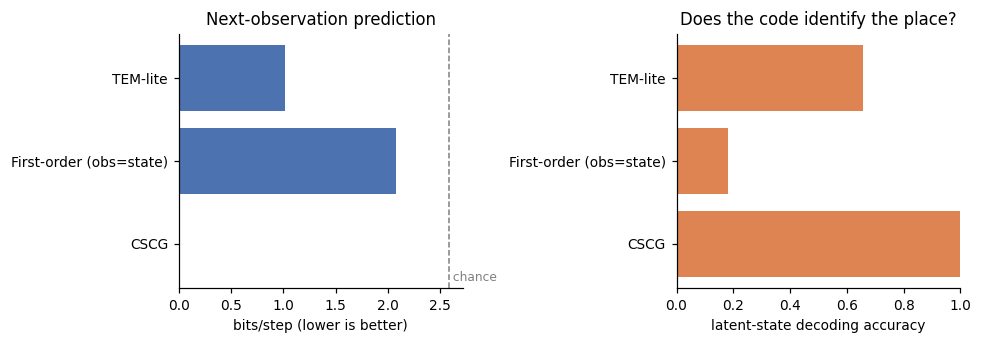

In [ ]:
r = {k: v for k, v in RESULTS["A"].items() if not k.startswith("_")}
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
names = list(r)
ax[0].barh(names, [r[n]["bits"] for n in names], color="#4C72B0")
ax[0].axvline(np.log2(6), ls="--", c="grey", lw=1)
ax[0].text(np.log2(6), -0.45, " chance", color="grey", fontsize=8)
ax[0].set_xlabel("bits/step (lower is better)")
ax[0].set_title("Next-observation prediction")
ax[1].barh(names, [r[n]["state_acc"] for n in names], color="#DD8452")
ax[1].set_xlim(0, 1); ax[1].set_xlabel("latent-state decoding accuracy")
ax[1].set_title("Does the code identify the place?")
plt.tight_layout(); plt.show()

## Experiment B — transitive stitching, then planning a shortcut

The agent experiences a 6×10 room in **temporally disjoint episodes**: some
confined to the left half, some to the right, overlapping only in the middle
columns. No single episode ever crosses the room.

Then we ask for a route from the far-left column to the far-right column — a
path the agent has never traversed. The route is planned by message passing over
the **learned latent graph** and then *executed in the real world*; success means
it actually arrives, and `excess_steps` is how far the route falls short of the
true geodesic.

This targets paper 2's specific claim that TEMs "do not do latent transitive
stitching." Note the asymmetry it exposes: CSCG's map is an explicit, editable
graph, so planning is a graph search over it. TEM-lite's map is the weights of a
generative model plus an associative memory, and route planning is not available
without adding machinery. That is a structural difference between the theories,
not a tuning detail.

In [ ]:
RESULTS["B"] = experiment_B(cfg)

  TEM step    0  train bits/step 4.5311
  TEM step   50  train bits/step 1.8123
  TEM step  100  train bits/step 1.6245
  TEM step  150  train bits/step 1.6237
  TEM step  200  train bits/step 1.5595
  TEM step  250  train bits/step 1.5561
  TEM step  300  train bits/step 1.6056
  TEM step  350  train bits/step 1.5618
  TEM step  399  train bits/step 1.5461

Experiment B - transitive stitching + planning
  model                                  bits    state_acc plan_success excess_steps         secs
  -----------------------------------------------------------------------------------------------
  CSCG                                  0.002        1.000        1.000        0.000       26.162
  TEM-lite                              1.533          nan          nan          nan       87.592
  note: TEM-lite has no explicit editable latent graph, so route planning is not available without adding a mechanism; this is the asymmetry Raju et al. emphasise.


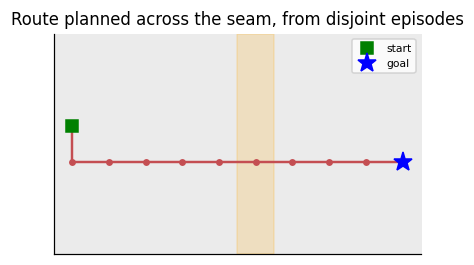

In [ ]:
w = RESULTS["B"]["_world"]; cs = RESULTS["B"]["_models"]["cscg"]
cells = w.meta["cells"]; H, W = w.meta["shape"]
at, xt, st = w.random_walk(cfg["test_steps"], np.random.default_rng(11))
dec = cs.decode(at, xt)
s0 = int(np.flatnonzero(cells[:, 1] == 0)[2]); s1 = int(np.flatnonzero(cells[:, 1] == W - 1)[3])
i0, i1 = np.flatnonzero(st == s0), np.flatnonzero(st == s1)
if len(i0) and len(i1):
    acts, _ = cs.plan(dec[i0[0]], dec[i1[0]], thresh=cfg["plan_thresh"])
    grid = np.zeros((H, W)); s = s0; pts = [cells[s]]
    for a in (acts or []):
        n = w.trans[s, a]
        if n < 0: break
        s = int(n); pts.append(cells[s])
    pts = np.array(pts)
    grid[cells[:, 0], cells[:, 1]] = 0.15
    plt.figure(figsize=(5, 2.6))
    plt.imshow(grid, cmap="Greys", vmin=0, vmax=1)
    plt.plot(pts[:, 1], pts[:, 0], "-o", ms=3.5, c="#C44E52", lw=1.6)
    plt.plot(cells[s0][1], cells[s0][0], "s", c="green", ms=8, label="start")
    plt.plot(cells[s1][1], cells[s1][0], "*", c="blue", ms=13, label="goal")
    plt.axvspan(4.5, 5.5, color="orange", alpha=.18)
    plt.title("Route planned across the seam, from disjoint episodes")
    plt.legend(fontsize=7); plt.xticks([]); plt.yticks([]); plt.show()

## Experiment C — structural transfer to a new sensory world

**This is paper 1's headline claim, and the experiment that most favours it.**

The topology is held fixed and every sensory identity is redrawn. Three
protocols are compared as a function of how much experience the agent has had in
the *new* world:

* **TEM-lite (online binding).** Structure was meta-learned across many sensory
  worlds; the new one is bound into episodic memory online, with no weight
  updates at all.
* **CSCG (freeze T, relearn E).** The paper 2 transfer protocol: treat the
  learned graph as a schema, re-estimate only the emission matrix.
* **CSCG (from scratch).** Relearn everything. The control.

**The expected shape of the result is the interesting part.** TEM-lite should
win decisively when experience is scarce — that is what factorisation buys.
CSCG-from-scratch should overtake everything once experience is plentiful,
because its asymptote is lower. Fast binding with a higher floor, versus slower
learning with a lower floor. Neither theory is simply "better"; they are betting
on different regimes.

In [ ]:
RESULTS["C"] = experiment_C(cfg)

  TEM step    0  train bits/step 4.0786
  TEM step   50  train bits/step 1.8459
  TEM step  100  train bits/step 1.6540
  TEM step  150  train bits/step 1.6064
  TEM step  200  train bits/step 1.6290
  TEM step  250  train bits/step 1.6847
  TEM step  300  train bits/step 1.6399
  TEM step  350  train bits/step 1.5573
  TEM step  399  train bits/step 1.5923

steps in new sensory world               50      150      400     1000     2000     4000
CSCG (freeze T, relearn E)            2.904    2.229    0.478    0.009    0.009    0.008
CSCG (from scratch)                   2.474    2.251    1.646    0.507    0.083    0.004
TEM-lite (online binding)             1.332    1.339    1.382    1.272    1.198    1.119
(values are bits/step on held-out walks; lower is better)


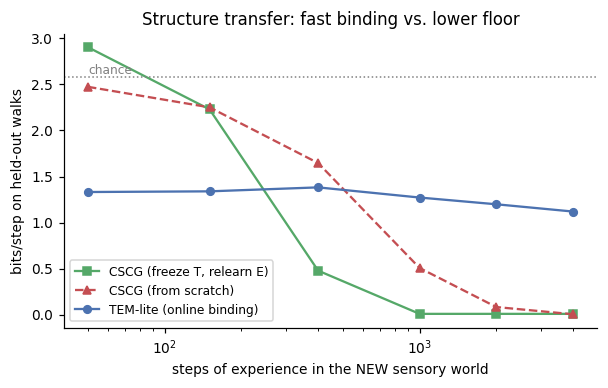

In [ ]:
c = RESULTS["C"]; b = c["budgets"]
plt.figure(figsize=(5.6, 3.6))
styles = {"TEM-lite (online binding)": ("#4C72B0", "-o"),
          "CSCG (freeze T, relearn E)": ("#55A868", "-s"),
          "CSCG (from scratch)": ("#C44E52", "--^")}
for k, v in c["curves"].items():
    col, st_ = styles[k]
    plt.plot(b, v, st_, color=col, label=k, ms=5)
plt.axhline(np.log2(6), ls=":", c="grey", lw=1)
plt.text(b[0], np.log2(6) + .03, "chance", color="grey", fontsize=8)
plt.xscale("log"); plt.xlabel("steps of experience in the NEW sensory world")
plt.ylabel("bits/step on held-out walks")
plt.title("Structure transfer: fast binding vs. lower floor")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## Experiment D — non-spatial relational structure

Both theories claim to cover more than space, so we hand them a random
reversible relational graph (actions are abstract relations, nothing Euclidean
anywhere) and a hierarchy.

**Read this table with the caveat that follows it.** TEM-lite's grid-module code
assumes actions **commute** — an abelian group, which describes 2-D translation
but not an arbitrary relational graph. The published TEM uses general learned
transition weights and *has* been demonstrated on non-spatial relational tasks
such as transitive inference and social hierarchies. So a poor TEM-lite row here
scores **this notebook's reduction, not the theory**. It would be
straightforwardly unfair to read it as CSCG beating TEM on relational structure.

The ablation at the end shows the bind: the unconstrained version that *could*
represent these graphs is the one that will not train.

In [ ]:
RESULTS["D"] = experiment_D(cfg)


Experiment D - relational graph (36 latent states)
  model                                  bits    state_acc         secs
  ---------------------------------------------------------------------
  CSCG                                  0.032        1.000       23.307
  TEM-lite                              2.396        0.045       84.409

Experiment D - hierarchy (tree) (15 latent states)
  model                                  bits    state_acc         secs
  ---------------------------------------------------------------------
  CSCG                                  0.012        1.000       25.467
  TEM-lite                              1.098        0.354       82.542

  CAVEAT: TEM-lite's grid-module code assumes actions COMMUTE
  (an abelian group), which covers 2-D translation but not an
  arbitrary relational graph. The published TEM uses general
  learned transition weights and HAS been demonstrated on
  non-spatial relational tasks. These rows therefore score the
  reduction u

## Experiment E — egocentric actions, no compass

Latent state is (cell, heading); actions are forward / turn-left / turn-right.
Turning and moving **do not commute**, so an additive phase code cannot
represent position however well its frequencies are tuned.

This is the sharpest empirical form of paper 2's critique — that spatial
representation should emerge from egocentric sensations and actions, without a
global coordinate frame. `cell_acc` asks whether the structural code recovers
*location* after marginalising over heading.

A fair reading: this is a genuine limitation of the *specific* structural code
used here, and the published TEM's learned transition weights are not restricted
to commuting operators. But paper 2's broader point stands independently —
whatever the architecture, an allocentric action algebra has to come from
somewhere, and in this implementation it had to be supplied by hand.

In [ ]:
RESULTS["E"] = experiment_E(cfg)

  TEM step    0  train bits/step 4.7070
  TEM step   50  train bits/step 1.8232
  TEM step  100  train bits/step 1.6704
  TEM step  150  train bits/step 1.6789
  TEM step  200  train bits/step 1.6280
  TEM step  250  train bits/step 1.6035
  TEM step  300  train bits/step 1.6593
  TEM step  350  train bits/step 1.7312
  TEM step  399  train bits/step 1.7126

Experiment E - egocentric actions (no compass)
  model                                  bits    state_acc     cell_acc         secs
  ----------------------------------------------------------------------------------
  CSCG                                  0.430        0.241        0.323       27.539
  TEM-lite                              1.895        0.030        0.095       88.271


## Experiment F — place fields as an artefact of the experimenter

Paper 2's most provocative claim is methodological: *"place field mapping should
be treated as just a visualization tool that the experimenter has at their
disposal."* The model has no mechanism for computing a place field and never
needs one; the field appears only when *we* project sequential responses onto a
Euclidean map.

Here we do exactly that. A CSCG is trained in a small uniform square room — one
repeated interior sensation, distinct walls and corners, so nothing local
identifies an interior location. Then, **without any further learning**, we
compute "place fields" in rooms of different shapes.

Three published phenomena should fall out of pure sequence learning:

1. **Fields enlarge toward the room centre.** Away from walls, long stretches of
   trajectory look identical, so the learner cannot split those contexts into
   separate clones. Aliasing of long temporal contexts *is* field expansion.
2. **Fields split when the room is elongated**, because one sequential context
   now occurs in two places.
3. **The split components are direction-selective**, since only one of the
   contexts arises on a directional traverse. Paper 2 notes that a purely
   geometric boundary-vector account offers no explanation for this.

In [ ]:
RESULTS["F"] = experiment_F(cfg)

Experiment F - place-field phenomenology from pure sequence learning
  mean field size vs distance from the wall (uniform room):
    border distance 0: field size 1.24 cells
    border distance 1: field size 1.26 cells
    border distance 2: field size 2.38 cells
    border distance 3: field size 2.33 cells


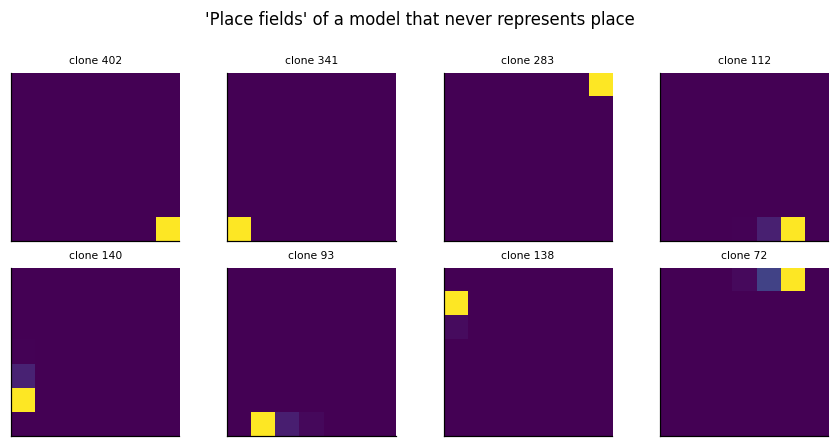

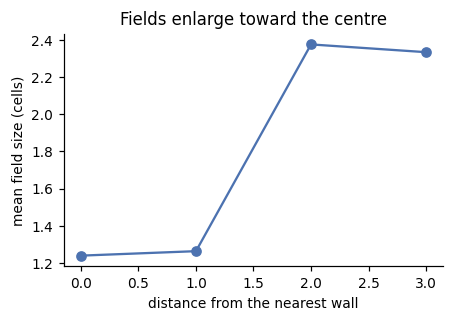

In [ ]:
f = RESULTS["F"]; base = f["fields"]["square 7x7"]; shp = f["shapes"]["square 7x7"]
peaks = base.max(1); order = np.argsort(-peaks)
sel = [i for i in order if peaks[i] > 1e-3][:8]
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ax, i in zip(axes.ravel(), sel):
    ax.imshow(base[i].reshape(shp), cmap="viridis")
    ax.set_title(f"clone {i}", fontsize=7); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("'Place fields' of a model that never represents place", y=1.0)
plt.tight_layout(); plt.show()

d = f["size_by_border_distance"]
plt.figure(figsize=(4.2, 3))
plt.plot(list(d), list(d.values()), "-o", color="#4C72B0")
plt.xlabel("distance from the nearest wall"); plt.ylabel("mean field size (cells)")
plt.title("Fields enlarge toward the centre"); plt.tight_layout(); plt.show()

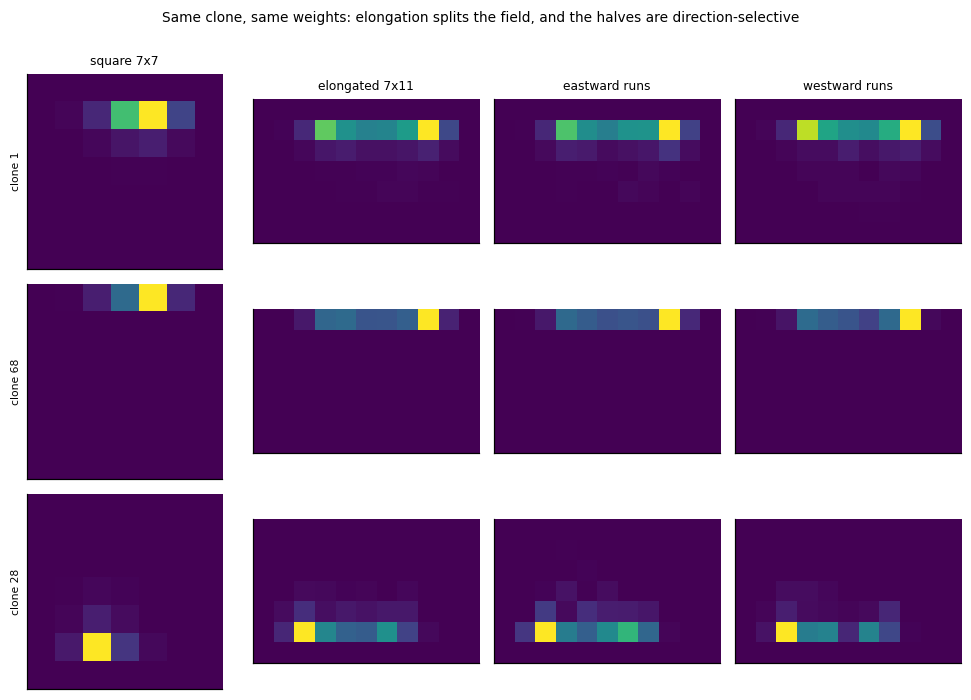

In [ ]:
# Elongation and direction selectivity
fields, shapes, dirf = f["fields"], f["shapes"], f["dir_fields"]
hor = fields["horizontal 7x11"]
score = np.array([(hor[i].max() * (hor[i] > .3 * hor[i].max()).sum())
                  if hor[i].max() > 1e-3 else 0.0 for i in range(hor.shape[0])])
split = np.argsort(-score)[:3]
fig, axes = plt.subplots(len(split), 4, figsize=(9, 2.1 * len(split)))
axes = np.atleast_2d(axes)
for r_, i in enumerate(split):
    for c_, (tag, arr, sh) in enumerate([
            ("square 7x7", fields["square 7x7"], shapes["square 7x7"]),
            ("elongated 7x11", hor, shapes["horizontal 7x11"]),
            ("eastward runs", dirf["eastward"], shapes["horizontal 7x11"]),
            ("westward runs", dirf["westward"], shapes["horizontal 7x11"])]):
        axes[r_, c_].imshow(arr[i].reshape(sh), cmap="viridis")
        axes[r_, c_].set_xticks([]); axes[r_, c_].set_yticks([])
        if r_ == 0: axes[r_, c_].set_title(tag, fontsize=8)
    axes[r_, 0].set_ylabel(f"clone {i}", fontsize=7)
fig.suptitle("Same clone, same weights: elongation splits the field, "
             "and the halves are direction-selective", y=1.0, fontsize=9)
plt.tight_layout(); plt.show()

## Ablation — what the structural code is actually assuming

Three versions of TEM-lite's structural code, everything else identical:

1. grid modules **with** action inverses supplied (what the experiments above use),
2. grid modules with inverses **withheld** (the model must discover that N undoes S),
3. **general** unconstrained matrices per action — the assumption-free version.

This is the honest cost of the reduction, and it is worth more than a paragraph
of hedging: it shows how much of the factorised model's success in this notebook
rests on built-in action algebra rather than on learning.

In [ ]:
RESULTS["ablation"] = ablation_general_structure(cfg)


Ablation - what the structural code assumes
  model                                  bits    state_acc         secs
  ---------------------------------------------------------------------
  modules + action inverses             1.017          nan       86.122
  modules, inverses withheld            2.064          nan       94.664
  general matrices (no algebra)         2.587          nan       88.906
  chance (log2 n_obs)                   2.585          nan        0.000


## Summary

Run the cell below after the experiments to collect everything into one table.

In [ ]:
rows = []
def add(exp, model, **kw): rows.append(dict(experiment=exp, model=model, **kw))
for name, title in [("A", "one aliased room"), ("B", "stitching + planning"),
                    ("E", "egocentric, no compass")]:
    if name in RESULTS:
        for m, v in RESULTS[name].items():
            if m.startswith("_"): continue
            add(title, m, bits=round(v.get("bits", np.nan), 3),
                state_acc=round(v.get("state_acc", np.nan), 3),
                secs=round(v.get("secs", np.nan), 1))
if "D" in RESULTS:
    for world, r in RESULTS["D"].items():
        for m, v in r.items():
            add(world, m, bits=round(v["bits"], 3),
                state_acc=round(v["state_acc"], 3), secs=round(v["secs"], 1))
try:
    import pandas as pd
    print(pd.DataFrame(rows).to_string(index=False))
except ImportError:
    for r_ in rows:
        print(r_)

            experiment                   model  bits  state_acc  secs
      one aliased room                    CSCG 0.004      0.998  24.1
      one aliased room First-order (obs=state) 2.080      0.183   0.0
      one aliased room                TEM-lite 1.017      0.655  91.1
  stitching + planning                    CSCG 0.002      1.000  26.2
  stitching + planning                TEM-lite 1.533        NaN  87.6
egocentric, no compass                    CSCG 0.430      0.241  27.5
egocentric, no compass                TEM-lite 1.895      0.030  88.3
      relational graph                    CSCG 0.032      1.000  23.3
      relational graph                TEM-lite 2.396      0.045  84.4
      hierarchy (tree)                    CSCG 0.012      1.000  25.5
      hierarchy (tree)                TEM-lite 1.098      0.354  82.5


## What the benchmark actually shows

Fill in your own numbers, but in development runs the pattern was consistent.

**Where CSCG wins, and why.** Under aliasing it recovers the latent topology
almost exactly and predicts near-perfectly, because splitting one observation
into many context-specific clones is *directly* the right hypothesis class for
this problem. It stitches disjoint episodes into a global map and then plans
optimal routes across a seam it never traversed. Its map is an explicit graph,
so planning is graph search and a blocked corridor is an edge deletion. And it
reproduces place-field enlargement, splitting, and direction selectivity from
one mechanism — long temporal contexts that the learner cannot tell apart —
without any geometry.

**Where the factorised theory wins, and why.** When the sensory world is redrawn
but the structure is preserved, TEM-lite binds a new environment in tens of
steps, with no weight updates, while CSCG needs orders of magnitude more data to
reach the same point. Factorisation is *exactly* a bet that structure recurs and
sensation does not, and when that bet is right it pays immediately. CSCG's own
schema-transfer protocol is a partial concession to the same idea — it works,
but it required the experimenter to decide by hand which matrix to freeze.

**The honest verdict is that they are betting on different regimes**, and the
transfer curve in Experiment C is the clearest picture of it: fast binding with
a higher floor, versus slower learning with a lower floor. They are also not
strictly rivals. Paper 2 says as much — grid inputs, if available, can be fed to
a CSCG as additional sensations to stabilise fields away from boundaries. A
model with a path-integrating structural code *and* clone-style context
splitting is not ruled out by anything measured here, and would be the obvious
next thing to build.

**What this notebook cannot settle.** Neither the neural evidence nor the
scaling behaviour. Every TEM-lite result is bounded by the reduction documented
in section 3, and Experiments D and E in particular measure that reduction's
abelian action algebra rather than the published model. Rooms of 40–120 states
are also far too small to probe how EM over clones scales when the environment
is large and the observations are high-dimensional images — which is where a
gradient-trained model would be expected to close ground.

---

## Extending this

* **Swap in the real TEM** from the official repository and rerun A, C and E;
  the harness only needs `predictive_bits`.
* **Give CSCG grid inputs.** Concatenate a phase code onto the observation
  alphabet and re-run F — paper 2 predicts fields stabilise away from walls.
* **Test remapping directly.** `resample_obs` plus partial cue rotation
  reproduces the Muller–Kubie manipulations in the paper's Table 1.
* **Break the environment mid-episode.** Delete edges from `cs.T` and re-plan;
  compare with retraining TEM-lite, which has no comparable edit operation.
* **Scale up.** Move to a 3-D environment with image observations and a vector
  quantiser in front of the CSCG, as the paper does.

## References

1. Whittington, J.C.R., McCaffary, D., Bakermans, J.J.W. & Behrens, T.E.J.
   *How to build a cognitive map.* Nat. Neurosci. **25**, 1257–1272 (2022).
2. Raju, R.V., Guntupalli, J.S., Zhou, G., Wendelken, C., Lázaro-Gredilla, M. &
   George, D. *Space is a latent sequence: A theory of the hippocampus.*
   Sci. Adv. **10**, eadm8470 (2024).
3. Whittington, J.C.R. et al. *The Tolman–Eichenbaum machine.* Cell **183**,
   1249–1263 (2020).
4. George, D. et al. *Clone-structured graph representations enable flexible
   learning and vicarious evaluation of cognitive maps.* Nat. Commun. **12**,
   2392 (2021).
5. Stachenfeld, K.L., Botvinick, M.M. & Gershman, S.J. *The hippocampus as a
   predictive map.* Nat. Neurosci. **20**, 1643–1653 (2017).